In [6]:
# Step 1 — Read input data (used globally across the whole tuning script)  #

from dataclasses import dataclass  # Data container #
import argparse  # CLI parsing #

@dataclass(frozen=True)
class ProcessData:
    k: float        # Process gain [-] #
    T0: float       # Dead time [s] #
    T: float        # Process time constant [s] #
    pv_lag: float   # PV lag time [s] #

def _as_float(name: str, v) -> float:  # Parse float with a clear error #
    try:
        return float(v)
    except Exception as e:
        raise ValueError(f"{name} must be a number, got: {v!r}") from e

def _validate(P: ProcessData) -> ProcessData:  # Basic sanity checks #
    if P.k == 0.0:
        raise ValueError("k (process gain) must be non-zero (sign is allowed).")
    if P.T0 <= 0.0:
        raise ValueError("T0 (dead time) must be > 0 [s].")
    if P.T <= 0.0:
        raise ValueError("T (time constant) must be > 0 [s].")
    if P.pv_lag < 0.0:
        raise ValueError("pv_lag must be >= 0 [s].")
    return P

def read_process_data() -> ProcessData:  # Read from CLI; fall back to interactive if missing #
    ap = argparse.ArgumentParser(add_help=True)
    ap.add_argument("--k", required=False, help="Process gain [-]")
    ap.add_argument("--T0", required=False, help="Dead time [s]")
    ap.add_argument("--T", required=False, help="Process time constant [s]")
    ap.add_argument("--pv_lag", required=False, help="PV lag time [s]")
    args, _ = ap.parse_known_args()

    k = args.k if args.k is not None else input("Enter process gain k [-]: ").strip()
    T0 = args.T0 if args.T0 is not None else input("Enter dead time T0 [s]: ").strip()
    T = args.T if args.T is not None else input("Enter process time constant T [s]: ").strip()
    pv_lag = args.pv_lag if args.pv_lag is not None else input("Enter PV lag time [s] (0 if none): ").strip()

    P = ProcessData(
        k=_as_float("k", k),
        T0=_as_float("T0", T0),
        T=_as_float("T", T),
        pv_lag=_as_float("pv_lag", pv_lag),
    )
    return _validate(P)

P = read_process_data()  # Global process data used in all tuning calculations #

Enter process gain k [-]: 6
Enter dead time T0 [s]: 0.1
Enter process time constant T [s]: 15
Enter PV lag time [s] (0 if none): 1


In [7]:
# Ziegler–Nichols (Step Response) tuning — parallel form: Gc(s)=Kp + Ki/s + Kd*s  #

import math  # inf #
import pandas as pd  # table #

def zn_step_response_parallel(P):  # Use global ProcessData P #
    K = P.k  # Process gain [-] #
    L = P.T0  # Dead time [s] #
    Tau = P.T  # Time constant [s] #

    Kp_P = 1.0 * Tau / (K * L)  # Z-N: k*T0/T=1.0 -> Kp=T/(k*T0) #
    Kp_PI = 0.9 * Tau / (K * L)  # Z-N: 0.9 #
    Ti_PI = 3.3 * L  # Z-N: Ti/T0=3.3 #
    Kp_PID = 1.2 * Tau / (K * L)  # Z-N: 1.2 #
    Ti_PID = 2.0 * L  # Z-N: Ti/T0=2 #
    Td_PID = 0.5 * L  # Z-N: Td/T0=0.5 #

    rows = []  # Collect rows #
    rows.append({  # P #
        "Controller": "P",
        "Kp": Kp_P,
        "Ti_s": math.inf,
        "Td_s": 0.0,
        "Ki": 0.0,
        "Kd": 0.0,
    })
    rows.append({  # PI #
        "Controller": "PI",
        "Kp": Kp_PI,
        "Ti_s": Ti_PI,
        "Td_s": 0.0,
        "Ki": Kp_PI / Ti_PI,
        "Kd": 0.0,
    })
    rows.append({  # PID #
        "Controller": "PID",
        "Kp": Kp_PID,
        "Ti_s": Ti_PID,
        "Td_s": Td_PID,
        "Ki": Kp_PID / Ti_PID,
        "Kd": Kp_PID * Td_PID,
    })

    df_zn = pd.DataFrame(rows)  # Build table #
    return df_zn  # Return #

ratio = P.T0 / P.T  # Dead-time ratio #
band = (  # Text-based difficulty bands from the page #
    "easy (<0.1)" if ratio < 0.1 else
    "moderate (0.1–0.2)" if ratio < 0.2 else
    "difficult (0.2–0.7)" if ratio < 0.7 else
    "very difficult (>=0.7)"
)

df_zn = zn_step_response_parallel(P)  # Compute tunings #
print("ZIEGLER-NICOLS STEP RESPONSE - PARALELL EQUATION")
print("parallel form: Gc(s)=Kp + Ki/s + Kd*s")
print("----------------------------------------------")
print(f"T0/T = {ratio:.4f} -> {band}")  # Minimal reasoning check #
print("----------------------------------------------")
print(df_zn.to_string(index=False))  # Comparative table #

ZIEGLER-NICOLS STEP RESPONSE - PARALELL EQUATION
parallel form: Gc(s)=Kp + Ki/s + Kd*s
----------------------------------------------
T0/T = 0.0067 -> easy (<0.1)
----------------------------------------------
Controller   Kp  Ti_s  Td_s         Ki  Kd
         P 25.0   inf  0.00   0.000000 0.0
        PI 22.5  0.33  0.00  68.181818 0.0
       PID 30.0  0.20  0.05 150.000000 1.5


z – zakłócenie na wejściu obiektu (przed dynamiką procesu)
Czyli coś, co dodaje się do sygnału sterującego / strumienia na wejściu.
Przykłady: wahania dopływu surowca przed zbiornikiem, zmiana ciśnienia zasilania zaworu (efektywnie zmienia MV→flow), dodatkowy dopływ/odpływ „przed” modelem.

x – zakłócenie na wyjściu obiektu (po dynamice procesu)
Czyli coś, co dodaje się do PV na wyjściu (albo działa jako obciążenie „za” procesem).
Przykłady: nagły pobór z instalacji (load) w punkcie wyjścia, dopływ ciepła/strata ciepła wpływająca bezpośrednio na temperaturę mierzoną, dodatkowy upust/odbiór z ostatniego węzła.

In [8]:
# Table 3 (static plant), kappa ≈ 0 (no overshoot), tr-min — compute ISA + parallel equivalents  #

import math  # inf #
import pandas as pd  # table #

def table3_static_kappa0(P, case):  # case: "z" (input disturbance) or "x" (output disturbance) #
    k = P.k  # process gain [-] #
    T0 = P.T0  # dead time [s] #
    T = P.T  # time constant [s] #
    r = T0 / T  # T0/T [-] #

    rows = []  # output rows #

    if case == "z":  # z = disturbance at plant input #
        # k*T0/T values (dimensionless loop gain proxy) #
        a_P, a_PI, a_PID = 0.30, 0.60, 0.95  # from Table 3 #
        # Ti/T0 formulas/values #
        Ti_over_T0_PI = 0.8 + 0.5 / r  # 0.8 + 0.5/(T0/T) #
        Ti_over_T0_PID = 2.4  # constant #
        # Td/T0 values #
        Td_over_T0_PID = 0.4  # constant #

        # P #
        Kp = a_P * T / (k * T0)  # Kp from a = (k*Kp*T0/T) #
        rows.append({"Case": "kappa0_static_z", "Controller": "P", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": 0.0})

        # PI #
        Kp = a_PI * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PI * T0  # Ti [s] #
        rows.append({"Case": "kappa0_static_z", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0})

        # PID #
        Kp = a_PID * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PID * T0  # Ti [s] #
        Td = Td_over_T0_PID * T0  # Td [s] #
        rows.append({"Case": "kappa0_static_z", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td})

    elif case == "x":  # x = disturbance at plant output #
        a_P, a_PI, a_PID = 0.30, 0.35, 0.60  # from Table 3 #
        Ti_over_T0_PI = 1.17 / r  # 1.17/(T0/T) #
        Ti_over_T0_PID = 1.0 / r  # 1.0/(T0/T) #
        Td_over_T0_PID = 0.5  # constant #

        # P #
        Kp = a_P * T / (k * T0)  # Kp #
        rows.append({"Case": "kappa0_static_x", "Controller": "P", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": 0.0})

        # PI #
        Kp = a_PI * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PI * T0  # Ti [s] #
        rows.append({"Case": "kappa0_static_x", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0})

        # PID #
        Kp = a_PID * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PID * T0  # Ti [s] #
        Td = Td_over_T0_PID * T0  # Td [s] #
        rows.append({"Case": "kappa0_static_x", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td})

    else:
        raise ValueError('case must be "z" or "x"')

    df = pd.DataFrame(rows)  # to table #

    # Parallel equivalents for: Gc(s)=Kp + Ki/s + Kd*s  #
    df["Ki_parallel"] = df.apply(lambda r: 0.0 if not math.isfinite(r["Ti_s"]) else r["Kp_ISA"] / r["Ti_s"], axis=1)  # Ki=Kp/Ti #
    df["Kd_parallel"] = df["Kp_ISA"] * df["Td_s"]  # Kd=Kp*Td #
    return df  # done #

df_t3_k0 = pd.concat(  # both disturbance locations #
    [table3_static_kappa0(P, "z"), table3_static_kappa0(P, "x")],
    ignore_index=True,
)
print("TABLE 3 (static plant), kappa ≈ 0 (no overshoot), tr-min")
print("--------------------------------------------------------")
print("z - disturbance on input to process")
print("--------------------------------------------------------")
print("x - disturbance on output of process")
print("--------------------------------------------------------")
print(df_t3_k0.to_string(index=False))  # comparative table #

TABLE 3 (static plant), kappa ≈ 0 (no overshoot), tr-min
--------------------------------------------------------
z - disturbance on input to process
--------------------------------------------------------
x - disturbance on output of process
--------------------------------------------------------
           Case Controller  Kp_ISA  Ti_s  Td_s  Ki_parallel  Kd_parallel
kappa0_static_z          P    7.50   inf  0.00     0.000000         0.00
kappa0_static_z         PI   15.00  7.58  0.00     1.978892         0.00
kappa0_static_z        PID   23.75  0.24  0.04    98.958333         0.95
kappa0_static_x          P    7.50   inf  0.00     0.000000         0.00
kappa0_static_x         PI    8.75 17.55  0.00     0.498575         0.00
kappa0_static_x        PID   15.00 15.00  0.05     1.000000         0.75


In [9]:
# Table 3 (static plant), kappa ≈ 20% (overshoot), tr-min  #

def table3_static_kappa20(P, case):  # case: "z" (input disturbance) or "x" (output disturbance) #
    k = P.k  # process gain [-] #
    T0 = P.T0  # dead time [s] #
    T = P.T  # time constant [s] #
    r = T0 / T  # T0/T [-] #

    rows = []  # rows #

    if case == "z":  # z = disturbance on input to process #
        a_P, a_PI, a_PID = 0.70, 0.70, 1.20  # k*T0/T from Table 3 #
        Ti_over_T0_PI = 1.0 + 0.3 / r  # 1 + 0.3/(T0/T) #
        Ti_over_T0_PID = 2.0  # constant #
        Td_over_T0_PID = 0.4  # constant #

        Kp = a_P * T / (k * T0)  # Kp #
        rows.append({"Case": "kappa20_static_z", "Controller": "P", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": 0.0})

        Kp = a_PI * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PI * T0  # Ti [s] #
        rows.append({"Case": "kappa20_static_z", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0})

        Kp = a_PID * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PID * T0  # Ti [s] #
        Td = Td_over_T0_PID * T0  # Td [s] #
        rows.append({"Case": "kappa20_static_z", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td})

    elif case == "x":  # x = disturbance on output of process #
        a_P, a_PI, a_PID = 0.70, 0.60, 0.95  # k*T0/T from Table 3 #
        Ti_over_T0_PI = 1.0 / r  # 1.0/(T0/T) #
        Ti_over_T0_PID = 1.36 / r  # 1.36/(T0/T) #
        Td_over_T0_PID = 0.64  # constant #

        Kp = a_P * T / (k * T0)  # Kp #
        rows.append({"Case": "kappa20_static_x", "Controller": "P", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": 0.0})

        Kp = a_PI * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PI * T0  # Ti [s] #
        rows.append({"Case": "kappa20_static_x", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0})

        Kp = a_PID * T / (k * T0)  # Kp #
        Ti = Ti_over_T0_PID * T0  # Ti [s] #
        Td = Td_over_T0_PID * T0  # Td [s] #
        rows.append({"Case": "kappa20_static_x", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td})

    else:
        raise ValueError('case must be "z" or "x"')

    df = pd.DataFrame(rows)  # df #

    df["Ki_parallel"] = df.apply(lambda r: 0.0 if not math.isfinite(r["Ti_s"]) else r["Kp_ISA"] / r["Ti_s"], axis=1)  # Ki=Kp/Ti #
    df["Kd_parallel"] = df["Kp_ISA"] * df["Td_s"]  # Kd=Kp*Td #
    return df  # done #

df_t3_k20 = pd.concat([table3_static_kappa20(P, "z"), table3_static_kappa20(P, "x")], ignore_index=True)  # both cases #

print("TABLE 3 (static plant), kappa ≈ 20% (overshoot), tr-min")
print("--------------------------------------------------------")
print("z - disturbance on input to process")
print("--------------------------------------------------------")
print("x - disturbance on output of process")
print("--------------------------------------------------------")
print(df_t3_k20.to_string(index=False))

TABLE 3 (static plant), kappa ≈ 20% (overshoot), tr-min
--------------------------------------------------------
z - disturbance on input to process
--------------------------------------------------------
x - disturbance on output of process
--------------------------------------------------------
            Case Controller  Kp_ISA  Ti_s  Td_s  Ki_parallel  Kd_parallel
kappa20_static_z          P   17.50   inf 0.000     0.000000         0.00
kappa20_static_z         PI   17.50   4.6 0.000     3.804348         0.00
kappa20_static_z        PID   30.00   0.2 0.040   150.000000         1.20
kappa20_static_x          P   17.50   inf 0.000     0.000000         0.00
kappa20_static_x         PI   15.00  15.0 0.000     1.000000         0.00
kappa20_static_x        PID   23.75  20.4 0.064     1.164216         1.52


In [10]:
# Table 3 (static plant), min ∫ e^2 dt  #

def table3_static_min_ise(P):  # static plant, criterion: min ∫ e^2 dt, only z-case in Table 3 #
    k, T0, T = P.k, P.T0, P.T  # inputs #
    r = T0 / T  # T0/T #

    rows = []  # rows #

    # P (not provided in Table 3 for this criterion) #
    rows.append({"Case": "min_ISE_static_z", "Controller": "P", "Kp_ISA": "-", "Ti_s": "-", "Td_s": "-", "Ki_parallel": "-", "Kd_parallel": "-"})

    # PI #
    a_PI = 1.0  # k*T0/T #
    Kp = a_PI * T / (k * T0)  # Kp #
    Ti = (1.0 + 0.35 / r) * T0  # Ti/T0 = 1 + 0.35/(T0/T) #
    rows.append({"Case": "min_ISE_static_z", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0, "Ki_parallel": Kp / Ti, "Kd_parallel": 0.0})

    # PID #
    a_PID = 1.40  # k*T0/T #
    Kp = a_PID * T / (k * T0)  # Kp #
    Ti = 1.3 * T0  # Ti/T0 = 1.3 #
    Td = 0.5 * T0  # Td/T0 = 0.5 #
    rows.append({"Case": "min_ISE_static_z", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td, "Ki_parallel": Kp / Ti, "Kd_parallel": Kp * Td})

    return pd.DataFrame(rows)  # df #

df_t3_min = table3_static_min_ise(P)  # compute #

print("TABLE 3 (static plant), min ∫ e^2 dt")
print("--------------------------------------------------------")
print("z - disturbance on input to process (only case available in Table 3)")
print("--------------------------------------------------------")
print("x - disturbance on output of process (not available for this criterion in Table 3)")
print("--------------------------------------------------------")
print(df_t3_min.to_string(index=False))

TABLE 3 (static plant), min ∫ e^2 dt
--------------------------------------------------------
z - disturbance on input to process (only case available in Table 3)
--------------------------------------------------------
x - disturbance on output of process (not available for this criterion in Table 3)
--------------------------------------------------------
            Case Controller Kp_ISA  Ti_s  Td_s Ki_parallel Kd_parallel
min_ISE_static_z          P      -     -     -           -           -
min_ISE_static_z         PI   25.0  5.35   0.0    4.672897         0.0
min_ISE_static_z        PID   35.0  0.13  0.05  269.230769        1.75


In [11]:
# Table 4 — Cohen–Coon (FOPDT), static plant  #

def cohen_coon_table4(P):
    k, T0, T = P.k, P.T0, P.T  # inputs #
    r = T0 / T  # T0/T [-] #

    rows = []  # rows #

    # P #
    a = 1.0 + r / 3.0  # k*Kp*T0/T #
    Kp = a * T / (k * T0)  # Kp #
    rows.append({"Case": "CC_Table4", "Controller": "P", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": 0.0})

    # PI #
    a = 0.9 + r / 12.0  # k*Kp*T0/T #
    Kp = a * T / (k * T0)  # Kp #
    Ti = ((30.0 + 3.0 * r) / (9.0 + 20.0 * r)) * T0  # Ti/T0 #
    rows.append({"Case": "CC_Table4", "Controller": "PI", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": 0.0})

    # PD #
    a = 1.25 + r / 6.0  # k*Kp*T0/T #
    Kp = a * T / (k * T0)  # Kp #
    Td = ((6.0 - 2.0 * r) / (22.0 + 3.0 * r)) * T0  # Td/T0 #
    rows.append({"Case": "CC_Table4", "Controller": "PD", "Kp_ISA": Kp, "Ti_s": math.inf, "Td_s": Td})

    # PID #
    a = 1.333 + r / 4.0  # k*Kp*T0/T #
    Kp = a * T / (k * T0)  # Kp #
    Ti = ((32.0 + 6.0 * r) / (13.0 + 8.0 * r)) * T0  # Ti/T0 #
    Td = (4.0 / (11.0 + 2.0 * r)) * T0  # Td/T0 #
    rows.append({"Case": "CC_Table4", "Controller": "PID", "Kp_ISA": Kp, "Ti_s": Ti, "Td_s": Td})

    df = pd.DataFrame(rows)  # df #
    df["Ki_parallel"] = df.apply(lambda rr: 0.0 if not math.isfinite(rr["Ti_s"]) else rr["Kp_ISA"] / rr["Ti_s"], axis=1)  # Ki=Kp/Ti #
    df["Kd_parallel"] = df["Kp_ISA"] * df["Td_s"]  # Kd=Kp*Td #
    return df

df_cc = cohen_coon_table4(P)

print("TABLE 4 (Cohen–Coon), static plant (FOPDT)")
print("------------------------------------------")
print(df_cc.to_string(index=False))

TABLE 4 (Cohen–Coon), static plant (FOPDT)
------------------------------------------
     Case Controller    Kp_ISA     Ti_s     Td_s  Ki_parallel  Kd_parallel
CC_Table4          P 25.055556      inf 0.000000     0.000000     0.000000
CC_Table4         PI 22.513889 0.328686 0.000000    68.496620     0.000000
CC_Table4         PD 31.277778      inf 0.027187     0.000000     0.850362
CC_Table4        PID 33.366667 0.245455 0.036320   135.938272     1.211864


In [12]:
# Honeywell Experion PID — CTLEQN = "A" (Equation A), convert ISA/parallel tunings to K, T1, T2  #

import math  # inf #
import pandas as pd  # df #

def to_honeywell_equation_a(df):  # df -> Honeywell EqA params #
    df = df.copy()  # keep original #
    kp_col = "Kp_ISA" if "Kp_ISA" in df.columns else "Kp"  # gain column #
    ti_col = "Ti_s" if "Ti_s" in df.columns else "Ti"  # integral time [s] #
    td_col = "Td_s" if "Td_s" in df.columns else "Td"  # derivative time [s] #

    def sec_to_min(x):  # [s] -> [min] #
        if isinstance(x, (int, float)):  # numeric #
            if not math.isfinite(x):  # inf #
                return math.inf
            return x / 60.0  # minutes #
        return x  # keep "-" etc. #

    df["CTLEQN"] = "A"  # Equation A #
    df["a"] = 1.0 / 16.0  # derivative filter constant (fixed) #
    df["K"] = df[kp_col]  # controller gain #
    df["T1_min"] = df[ti_col].apply(sec_to_min)  # integral time [min] #
    df["T2_min"] = df[td_col].apply(sec_to_min)  # derivative time [min] #

    keep = [c for c in ["Case", "Controller", "Ctrl", "CTLEQN", "a", "K", "T1_min", "T2_min"] if c in df.columns]  # tidy #
    return df[keep]  # return #

# Example: Ziegler–Nichols step-response results -> Honeywell EqA #
df_zn_eqA = to_honeywell_equation_a(df_zn)  # convert #

print("HONEYWELL EXPERION PID — Equation A (CTLEQN=A) — FROM Z-N STEP RESPONSE")
print("-----------------------------------------------------------------------")
print(df_zn_eqA.to_string(index=False))

HONEYWELL EXPERION PID — Equation A (CTLEQN=A) — FROM Z-N STEP RESPONSE
-----------------------------------------------------------------------
Controller CTLEQN      a    K   T1_min   T2_min
         P      A 0.0625 25.0      inf 0.000000
        PI      A 0.0625 22.5 0.005500 0.000000
       PID      A 0.0625 30.0 0.003333 0.000833


In [13]:
# Honeywell Experion PID — CTLEQN = "B" (Equation B), same K/T1/T2 but D acts on PV changes  #

import math  # inf #
import pandas as pd  # df #

def to_honeywell_equation_b(df):  # df -> Honeywell EqB params #
    df = df.copy()  # keep original #
    kp_col = "Kp_ISA" if "Kp_ISA" in df.columns else "Kp"  # gain column #
    ti_col = "Ti_s" if "Ti_s" in df.columns else "Ti"  # integral time [s] #
    td_col = "Td_s" if "Td_s" in df.columns else "Td"  # derivative time [s] #

    def sec_to_min(x):  # [s] -> [min] #
        if isinstance(x, (int, float)):  # numeric #
            if not math.isfinite(x):  # inf #
                return math.inf
            return x / 60.0  # minutes #
        return x  # keep "-" etc. #

    df["CTLEQN"] = "B"  # Equation B #
    df["a"] = 1.0 / 16.0  # derivative filter constant (fixed) #
    df["K"] = df[kp_col]  # controller gain #
    df["T1_min"] = df[ti_col].apply(sec_to_min)  # integral time [min] #
    df["T2_min"] = df[td_col].apply(sec_to_min)  # derivative time [min] #

    keep = [c for c in ["Case", "Controller", "Ctrl", "CTLEQN", "a", "K", "T1_min", "T2_min"] if c in df.columns]  # tidy #
    return df[keep]  # return #

# Example: Cohen–Coon results -> Honeywell EqB #
df_cc_eqB = to_honeywell_equation_b(df_cc)  # convert #

print("HONEYWELL EXPERION PID — Equation B (CTLEQN=B) — FROM COHEN–COON")
print("----------------------------------------------------------------")
print(df_cc_eqB.to_string(index=False))

HONEYWELL EXPERION PID — Equation B (CTLEQN=B) — FROM COHEN–COON
----------------------------------------------------------------
     Case Controller CTLEQN      a         K   T1_min   T2_min
CC_Table4          P      B 0.0625 25.055556      inf 0.000000
CC_Table4         PI      B 0.0625 22.513889 0.005478 0.000000
CC_Table4         PD      B 0.0625 31.277778      inf 0.000453
CC_Table4        PID      B 0.0625 33.366667 0.004091 0.000605


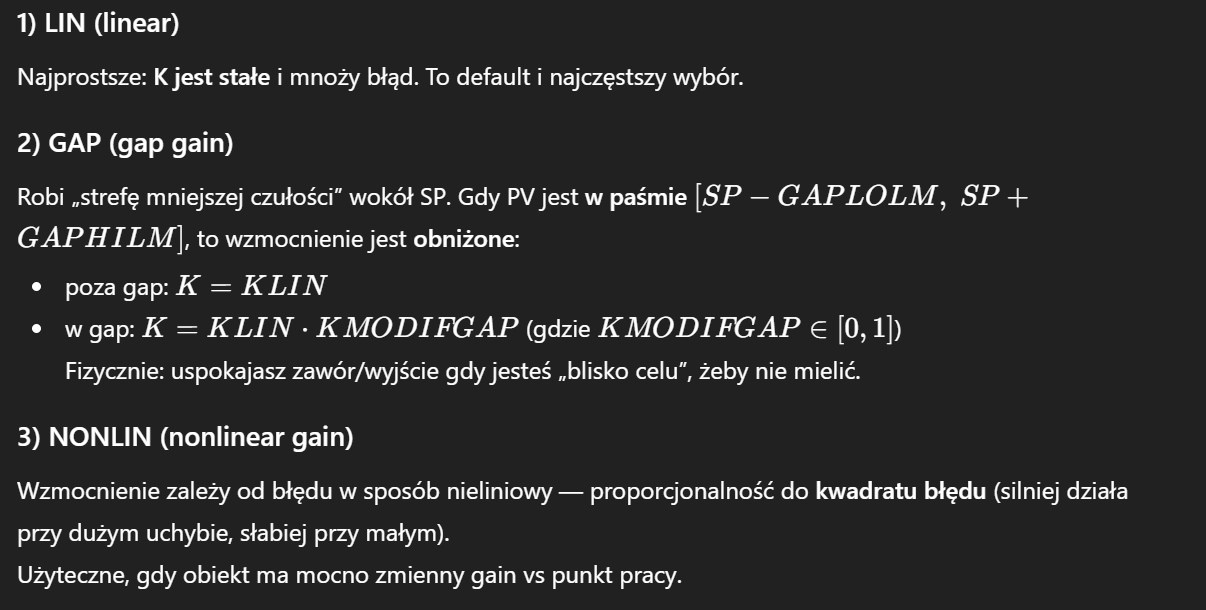